[load] source records: 40,078
[classes] instance counts: {'RegulatoryDocument': 16848, 'ESGReport': 15937, 'NewsArticle': 4764, 'LegalCase': 2529}
[OK] class sizes match the ontology design (A-1).
[derived] Sanction nodes (result present): 2,193
[derived] Jurisdiction nodes: 185
[edges] total: 122,477
[edges] by relation: {'inJurisdiction': 40078, 'issuedBy': 40078, 'aboutTopic': 40078, 'resultsInSanction': 2193, 'priorViolation': 50}
[edges] priorViolation by country: {'Vietnam': 13, 'Malaysia': 37}
[save] nodes (40,078) / edges (122,477)
[tables] class summary:
        node_class     n  countries
RegulatoryDocument 16848          2
         ESGReport 15937          2
       NewsArticle  4764          2
         LegalCase  2529          2
[tables] edge summary:
         relation  count
   inJurisdiction  40078
         issuedBy  40078
       aboutTopic  40078
resultsInSanction   2193
   priorViolation     50
[save] figure fig02_ontology (png, pdf)


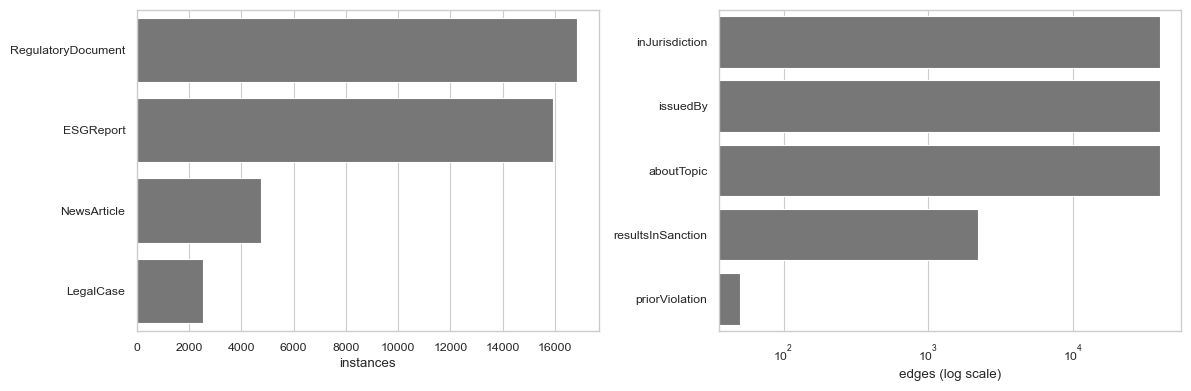


[done] notebook 02 complete.


In [1]:
# ============================================================================
# Notebook 02 · Ontology Construction (classes, properties, relations)
# ----------------------------------------------------------------------------
# Formalizes the source metadata into class instances (nodes) and GraphRAG
# relations (edges). Every class/property/relation is derived 1:1 from actual
# JSON fields (defensible: the ontology is not "forced" onto the data).
#
# Input : data/interim/source.parquet   (from notebook 01)
# Output: data/processed/nodes.parquet, data/processed/edges.parquet
#         results/tables/table02_*.csv, results/figures/fig02_* (png, pdf)
#
# Notes:
#   - Only DETERMINISTIC edges (directly derivable from fields) are built here.
#     Semi-automatic edges (governedBy / derivedFrom, which rely on sparse
#     clause references) are deferred to notebook 04 and human-reviewed there.
#   - All outputs are English-only; figures are grayscale, no titles, dpi=600.
# ============================================================================

import os
import json
import random
from pathlib import Path

import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------------------------------------------------------
# 0. Paths, seed, figure styling
# ----------------------------------------------------------------------------
PROJECT_ROOT  = Path.cwd().parent
INTERIM_DIR   = PROJECT_ROOT / "data" / "interim"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR   = PROJECT_ROOT / "results" / "figures"
TABLES_DIR    = PROJECT_ROOT / "results" / "tables"
for _d in (PROCESSED_DIR, FIGURES_DIR, TABLES_DIR):
    _d.mkdir(parents=True, exist_ok=True)

SEED = 42
random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

matplotlib.rcParams["axes.unicode_minus"] = False
pd.set_option("display.max_columns", 40)

sns.set_theme(style="whitegrid", context="paper")
sns.set_palette("Greys_r")
FIG_DPI = 600
GREY_DARK, GREY_MID, GREY_LIGHT = "#333333", "#777777", "#BBBBBB"

def save_fig(fig, stem):
    """Save a figure as both PNG and PDF at dpi=600 (no path printed)."""
    for ext in ("png", "pdf"):
        fig.savefig(FIGURES_DIR / f"{stem}.{ext}", dpi=FIG_DPI, bbox_inches="tight")
    print(f"[save] figure {stem} (png, pdf)")

# ----------------------------------------------------------------------------
# 1. Load parsed source (already English-normalized in notebook 01)
# ----------------------------------------------------------------------------
df = pd.read_parquet(INTERIM_DIR / "source.parquet")
print(f"[load] source records: {len(df):,}")

# ----------------------------------------------------------------------------
# 2. Class instances: map category -> ontology class
#    (English category names, as normalized in notebook 01)
# ----------------------------------------------------------------------------
CATEGORY_TO_CLASS = {
    "Regulation":   "RegulatoryDocument",
    "Legislation":  "RegulatoryDocument",
    "Legal case":   "LegalCase",
    "News":         "NewsArticle",
    "Gov/Corp ESG": "ESGReport",
    "Intl ESG":     "ESGReport",
}
df["node_class"] = df["category"].map(CATEGORY_TO_CLASS)

class_counts = df["node_class"].value_counts().to_dict()
print("[classes] instance counts:", class_counts)

# Cross-check against reported class sizes
assert class_counts["RegulatoryDocument"] == 9614 + 7234, class_counts
assert class_counts["LegalCase"]          == 2529,        class_counts
assert class_counts["ESGReport"]          == 7951 + 7986, class_counts
assert class_counts["NewsArticle"]        == 4764,        class_counts
print("[OK] class sizes match the ontology design (A-1).")

# ----------------------------------------------------------------------------
# 3. Node table (properties only; content excluded -> lightweight)
# ----------------------------------------------------------------------------
node_cols = [
    "id", "doc_id", "node_class", "category", "country", "region", "esg",
    "title", "document_type", "publisher", "entity", "published_at", "source",
    "reg_name", "reg_reference", "effective_date",
    "sanction_type", "sanction_level", "case_detail", "pollutant_category",
]
nodes = df[node_cols].copy()

# ----------------------------------------------------------------------------
# 4. Derived instances: Sanction (from case result), Jurisdiction (country/region)
# ----------------------------------------------------------------------------
sanctions = df[(df.node_class == "LegalCase") &
               (df.sanction_type.fillna("").str.strip() != "")].copy()
print(f"[derived] Sanction nodes (result present): {len(sanctions):,}")

juris = df[["country", "region"]].drop_duplicates().reset_index(drop=True)
print(f"[derived] Jurisdiction nodes: {len(juris)}")

# ----------------------------------------------------------------------------
# 5. Deterministic edges (directly derivable from fields)
#    resultsInSanction : LegalCase -> Sanction     (case_info.result)
#    inJurisdiction    : Document  -> Jurisdiction (country)
#    aboutTopic        : Document  -> ESGTopic     (esg)
#    issuedBy          : Document  -> Organization (publisher)
#    priorViolation    : LegalCase -> Violation    (previous_violations[*])
# ----------------------------------------------------------------------------
edges = []

for _, r in sanctions.iterrows():
    edges.append({"src": r["id"], "dst": f"SANCTION::{r['id']}",
                  "rel": "resultsInSanction", "evidence": "case_info.result"})

for _, r in df.iterrows():
    edges.append({"src": r["id"], "dst": f"JURIS::{r['country']}",
                  "rel": "inJurisdiction", "evidence": "country"})

for _, r in df[df.esg.isin(["E", "S", "G"])].iterrows():
    edges.append({"src": r["id"], "dst": f"TOPIC::{r['esg']}",
                  "rel": "aboutTopic", "evidence": "esg"})

for _, r in df[df.publisher.fillna("").str.strip() != ""].iterrows():
    edges.append({"src": r["id"], "dst": f"ORG::{r['publisher']}",
                  "rel": "issuedBy", "evidence": "publisher"})

edges_df = pd.DataFrame(edges)

# priorViolation: only cases whose previous_violations actually carry content
prior_rows, prior_by_country = [], {"Vietnam": 0, "Malaysia": 0}
for _, r in df[df.node_class == "LegalCase"].iterrows():
    pv = json.loads(r["previous_violations"])
    has_content = any(
        (v.get("violation_date") or v.get("violation_type") or v.get("penalty"))
        for v in pv if isinstance(v, dict)
    )
    if has_content:
        prior_rows.append({"src": r["id"], "dst": f"PRIORVIOL::{r['id']}",
                           "rel": "priorViolation", "evidence": "previous_violations"})
        prior_by_country[r["country"]] = prior_by_country.get(r["country"], 0) + 1
if prior_rows:
    edges_df = pd.concat([edges_df, pd.DataFrame(prior_rows)], ignore_index=True)

print(f"[edges] total: {len(edges_df):,}")
print("[edges] by relation:", edges_df["rel"].value_counts().to_dict())
print("[edges] priorViolation by country:", prior_by_country)

# ----------------------------------------------------------------------------
# 6. Save nodes / edges + summary tables + figure
# ----------------------------------------------------------------------------
nodes.to_parquet(PROCESSED_DIR / "nodes.parquet", index=False)
edges_df.to_parquet(PROCESSED_DIR / "edges.parquet", index=False)
print(f"[save] nodes ({len(nodes):,}) / edges ({len(edges_df):,})")

# Table 02: class summary
class_summary = (nodes.groupby("node_class")
                 .agg(n=("id", "count"), countries=("country", "nunique"))
                 .reset_index()
                 .sort_values("n", ascending=False))
class_summary.to_csv(TABLES_DIR / "table02_class_summary.csv",
                     index=False, encoding="utf-8-sig")

# Table 02b: edge summary
edge_summary = (edges_df["rel"].value_counts()
                .rename_axis("relation").reset_index(name="count"))
edge_summary.to_csv(TABLES_DIR / "table02b_edge_summary.csv",
                    index=False, encoding="utf-8-sig")

print("[tables] class summary:")
print(class_summary.to_string(index=False))
print("[tables] edge summary:")
print(edge_summary.to_string(index=False))

# Figure 02: class instance counts & edge relation counts (grayscale, no titles)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(x=class_summary["n"], y=class_summary["node_class"],
            color=GREY_MID, ax=axes[0])
axes[0].set_xlabel("instances")
axes[0].set_ylabel("")
sns.barplot(x=edge_summary["count"], y=edge_summary["relation"],
            color=GREY_MID, ax=axes[1])
axes[1].set_xlabel("edges (log scale)")
axes[1].set_ylabel("")
axes[1].set_xscale("log")
fig.tight_layout()
save_fig(fig, "fig02_ontology")
plt.show()

print("\n[done] notebook 02 complete.")